In [57]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

In [58]:
df = pd.read_csv('data/DoktorAvalanche_with_features_engineered_for_model.csv')

In [59]:
df.columns

Index(['move_number', 'increment_sec', 'time_left_sec', 'time_spent_sec',
       'time_left_ratio', 'eval_volatility', 'pieces_remaining',
       'material_density', 'num_minor_pieces', 'num_rooks', 'num_queens',
       'num_pawns', 'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'is_inaccuracy',
       'is_mistake', 'is_blunder', 'eval_unified', 'complexity_material_norm',
       'eval_volatility_norm', 'time_pressure_norm',
       'material_time_pressure_int', 'time_eval_volatility_int',
       'move_number_norm', 'late_endgame_int', 'cumulative_time_pressure',
       'color_white', 'time_left_ratio_clipped', 'time_left_bin'],
      dtype='

In [60]:
df = df.drop(['time_left_bin', 'is_blunder', 'is_mistake'], axis = 1)

In [61]:
df.columns

Index(['move_number', 'increment_sec', 'time_left_sec', 'time_spent_sec',
       'time_left_ratio', 'eval_volatility', 'pieces_remaining',
       'material_density', 'num_minor_pieces', 'num_rooks', 'num_queens',
       'num_pawns', 'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'is_inaccuracy',
       'eval_unified', 'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

In [62]:
# train test split
from sklearn.model_selection import train_test_split

X = df.drop('is_inaccuracy', axis=1)
y = df['is_inaccuracy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_df = pd.concat([X_train, y_train], axis=1)

In [63]:
X_train.shape

(20898, 42)

In [64]:
y_train.shape

(20898,)

In [65]:
y_train[y_train == 1].sum()

np.int64(1050)

In [66]:
X_test.shape

(5225, 42)

In [67]:
y_test[y_test == 1].sum()

np.int64(263)

In [68]:
X_test.to_csv('model_data/X_test_inaccuracy.csv', index=False)
y_test.to_csv('model_data/y_test_inaccuracy.csv', index=False)

In [69]:
# Numeric columns
numeric_columns = [
    col for col in df.columns
    if df[col].nunique() != 2 and col not in ['is_inaccuracy', 'is_mistake', 'is_blunder']
]
numeric_columns

['move_number',
 'increment_sec',
 'time_left_sec',
 'time_spent_sec',
 'time_left_ratio',
 'eval_volatility',
 'pieces_remaining',
 'material_density',
 'num_minor_pieces',
 'num_rooks',
 'num_queens',
 'num_pawns',
 'complexity_material_score',
 'avg_time_spent_per_move',
 'time_spent_ratio',
 'eval_unified',
 'complexity_material_norm',
 'eval_volatility_norm',
 'time_pressure_norm',
 'material_time_pressure_int',
 'time_eval_volatility_int',
 'move_number_norm',
 'late_endgame_int',
 'cumulative_time_pressure',
 'time_left_ratio_clipped']

In [70]:
def find_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print("q1:", Q1, "q3:", Q3, "IQR:", IQR, "lower_bound:", lower_bound, "upper_bound:", upper_bound)
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

for i in numeric_columns:
    print(i, ":", len(find_outliers_iqr(train_df[i])))

q1: 10.0 q3: 29.0 IQR: 19.0 lower_bound: -18.5 upper_bound: 57.5
move_number : 462
q1: 3.0 q3: 3.0 IQR: 0.0 lower_bound: 3.0 upper_bound: 3.0
increment_sec : 4493
q1: 102.43 q3: 272.83 IQR: 170.39999999999998 lower_bound: -153.16999999999996 upper_bound: 528.43
time_left_sec : 0
q1: 2.44 q3: 9.8 IQR: 7.360000000000001 lower_bound: -8.600000000000003 upper_bound: 20.840000000000003
time_spent_sec : 1678
q1: 0.3784166666666667 q3: 0.9401 IQR: 0.5616833333333333 lower_bound: -0.4641083333333333 upper_bound: 1.782625
time_left_ratio : 0
q1: 14.406122155374543 q3: 87.70911451217725 IQR: 73.3029923568027 lower_bound: -95.54836637982952 upper_bound: 197.66360304738132
eval_volatility : 2430
q1: 18.0 q3: 29.0 IQR: 11.0 lower_bound: 1.5 upper_bound: 45.5
pieces_remaining : 0
q1: 0.5625 q3: 0.90625 IQR: 0.34375 lower_bound: 0.046875 upper_bound: 1.421875
material_density : 0
q1: 3.0 q3: 7.0 IQR: 4.0 lower_bound: -3.0 upper_bound: 13.0
num_minor_pieces : 0
q1: 2.0 q3: 4.0 IQR: 2.0 lower_bound: -1

In [71]:
# Set option to display all rows
pd.set_option('display.max_rows', None)

In [72]:

train_df['move_number'].value_counts().sort_index(ascending = False)

move_number
91      1
90      1
88      2
87      1
86      2
85      3
84      3
83      3
82      2
81      3
80      4
79      4
78      5
77      6
76      7
75      7
74      9
73      6
72     11
71     12
70     12
69     15
68     18
67     23
66     20
65     26
64     24
63     27
62     32
61     37
60     41
59     45
58     50
57     60
56     59
55     66
54     71
53     77
52     84
51     94
50     98
49     92
48    114
47    118
46    119
45    128
44    137
43    150
42    157
41    155
40    178
39    193
38    198
37    219
36    223
35    237
34    269
33    278
32    293
31    315
30    351
29    386
28    401
27    408
26    451
25    466
24    499
23    504
22    531
21    542
20    575
19    564
18    596
17    620
16    617
15    653
14    646
13    645
12    664
11    686
10    687
9     663
8     690
7     678
6     676
5     677
4     696
3     682
Name: count, dtype: int64

In [73]:

train_df['increment_sec'].value_counts().sort_index(ascending = False)

increment_sec
5      232
4       41
3    16405
2     2785
0     1435
Name: count, dtype: int64

In [74]:
train_df['time_spent_sec'].value_counts().sort_index(ascending = False)

time_spent_sec
106.51      1
104.84      1
90.16       1
87.16       1
86.20       1
86.19       1
84.28       1
81.96       1
79.80       1
77.56       1
77.40       1
76.52       1
76.12       1
74.68       1
73.00       1
72.84       1
72.28       2
70.92       1
70.84       1
70.52       1
69.96       1
69.68       1
68.92       1
68.84       1
68.36       1
68.08       1
68.04       1
67.96       1
67.56       1
66.44       1
66.36       1
66.12       1
65.92       1
65.72       1
65.40       1
65.24       1
64.40       1
64.12       2
64.00       1
63.71       1
63.48       1
63.16       1
63.08       1
62.92       1
62.84       1
62.68       1
62.36       1
60.60       1
60.04       1
59.88       1
59.48       1
59.32       1
59.08       1
58.92       1
58.52       1
58.12       1
57.88       1
57.76       1
57.72       2
57.64       1
57.56       1
57.32       1
56.92       1
56.68       1
55.80       3
55.72       2
55.64       1
55.48       2
55.32       1
55.24       1
54.76

In [75]:
train_df['avg_time_spent_per_move'].value_counts().sort_index(ascending = False)

avg_time_spent_per_move
17.935000     8
16.581818     8
16.337500    11
15.926000    13
15.265909    15
15.113043    15
14.794348    18
14.330435    18
14.318333    15
14.120000    18
13.904667     9
13.875556    13
13.844375     8
13.835000    16
13.766957    14
13.526000    12
13.467727    15
13.275833    17
13.186667    20
13.001818    16
12.960000    14
12.957647    15
12.955862    20
12.950588    11
12.948276    18
12.820370    21
12.820000    21
12.788261    17
12.765769    19
12.758621    22
12.738400    22
12.640741    18
12.640000    24
12.605172    25
12.595500    14
12.471034    20
12.409677    25
12.397037    23
12.350476    14
12.251034    19
12.223214    23
12.210526    12
12.202414    22
12.188571    21
12.177500    18
12.082759    24
12.027308    18
12.027037    25
11.987600    16
11.971613    25
11.856842    14
11.823750    19
11.819259    19
11.767727    16
11.766364    18
11.754762    16
11.748148    21
11.724687    20
11.718710    23
11.707667    23
11.707586    26


In [76]:
train_df['eval_unified'].value_counts().sort_index(ascending = False)

eval_unified
 16955.400000     129
 16931.526923      44
 16907.653846      43
 16883.780769      48
 16859.907692      44
 16836.034615      43
 16812.161538      47
 16788.288462      24
 16764.415385      23
 16740.542308      19
 16716.669231      19
 16692.796154      23
 16668.923077       8
 16645.050000       8
 16621.176923      10
 16597.303846       2
 16573.430769       5
 16549.557692       4
 16525.684615       3
 16501.811538       3
 16477.938462       1
 16454.065385       1
 16382.446154       1
 16358.573077       3
 16334.700000       1
 16310.826923       2
 16286.953846       3
 16239.207692       1
 16215.334615       1
 16119.842308       1
 16072.096154       2
 16048.223077       1
 15785.619231       1
 15714.000000       1
 15414.000000       2
 14380.000000       1
 9407.000000        1
 8514.000000        1
 8433.000000        1
 8255.000000        1
 7818.000000        1
 7575.000000        1
 7550.000000        1
 7544.000000        1
 7466.000000       

In [77]:
df.columns

Index(['move_number', 'increment_sec', 'time_left_sec', 'time_spent_sec',
       'time_left_ratio', 'eval_volatility', 'pieces_remaining',
       'material_density', 'num_minor_pieces', 'num_rooks', 'num_queens',
       'num_pawns', 'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'is_inaccuracy',
       'eval_unified', 'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

Don't remove any outliers since these are all representative of data

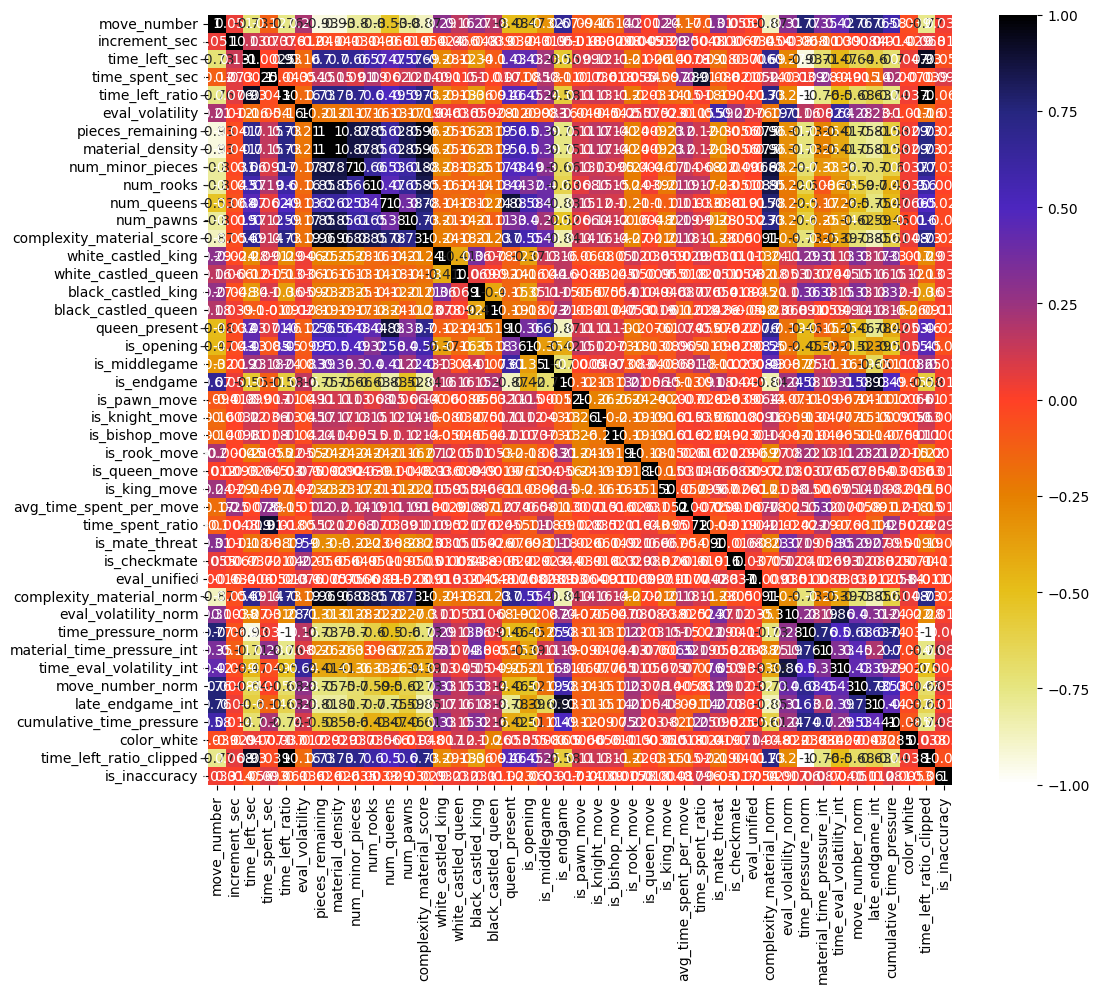

In [78]:
#Using Pearson Correlation
plt.figure(figsize=(12,10))
cor = train_df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
plt.show()

In [79]:
train_df.corr()

,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,eval_volatility,pieces_remaining,material_density,num_minor_pieces,num_rooks,...,eval_volatility_norm,time_pressure_norm,material_time_pressure_int,time_eval_volatility_int,move_number_norm,late_endgame_int,cumulative_time_pressure,color_white,time_left_ratio_clipped,is_inaccuracy
move_number,1.000000,0.051118,-0.726302,-0.123805,-0.762894,0.206015,-0.934773,-0.934773,-0.800685,-0.798898,...,0.309016,0.766738,0.346715,0.423612,0.758107,0.757983,0.583277,-0.039261,-0.766738,0.033216
increment_sec,0.051118,1.000000,0.129025,0.072535,0.075765,0.012088,-0.040907,-0.040907,-0.030811,-0.042743,...,0.003849,-0.068443,-0.112307,-0.039348,0.000837,0.040119,0.013880,-0.029450,0.068443,0.014117
time_left_sec,-0.726302,0.129025,1.000000,-0.002497,0.930568,-0.160736,0.697435,0.697435,0.664977,0.573167,...,-0.271221,-0.933816,-0.709153,-0.465712,-0.640227,-0.597002,-0.704873,0.047230,0.933816,-0.056315
time_spent_sec,-0.123805,0.072535,-0.002497,1.000000,-0.042552,-0.054357,0.152559,0.152559,0.090860,0.187779,...,-0.031420,0.038611,0.283601,-0.049040,-0.015165,-0.143873,0.204921,0.007070,-0.038611,0.093326
time_left_ratio,-0.762894,0.075765,0.930568,-0.042552,1.000000,-0.162855,0.731288,0.731288,0.697267,0.600096,...,-0.281454,-0.999185,-0.757951,-0.498353,-0.681965,-0.631772,-0.742358,0.037278,0.999185,-0.060602
eval_volatility,0.206015,0.012088,-0.160736,-0.054357,-0.162855,1.000000,-0.207216,-0.207216,-0.171871,-0.160826,...,0.711770,0.164791,0.081761,0.640085,0.276600,0.227919,0.103714,-0.016829,-0.164791,-0.036482
pieces_remaining,-0.934773,-0.040907,0.697435,0.152559,0.731288,-0.207216,1.000000,1.000000,0.866426,0.848942,...,-0.309136,-0.734766,-0.263279,-0.405131,-0.746204,-0.809330,-0.583156,0.028916,0.734766,-0.026075
material_density,-0.934773,-0.040907,0.697435,0.152559,0.731288,-0.207216,1.000000,1.000000,0.866426,0.848942,...,-0.309136,-0.734766,-0.263279,-0.405131,-0.746204,-0.809330,-0.583156,0.028916,0.734766,-0.026075
num_minor_pieces,-0.800685,-0.030811,0.664977,0.090860,0.697267,-0.171871,0.866426,0.866426,1.000000,0.655612,...,-0.278387,-0.699195,-0.328455,-0.358324,-0.704707,-0.697414,-0.601820,0.036529,0.699195,-0.035493
num_rooks,-0.798898,-0.042743,0.573167,0.187779,0.600096,-0.160826,0.848942,0.848942,0.655612,1.000000,...,-0.223826,-0.603712,-0.085501,-0.327049,-0.588220,-0.697112,-0.430051,0.034768,0.603712,-0.003296


In [80]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in the absolute coefficient value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [81]:
corr_features = correlation(train_df, 0.8)
len(set(corr_features))

15

In [82]:
corr_features

{'complexity_material_norm',
 'complexity_material_score',
 'is_endgame',
 'late_endgame_int',
 'material_density',
 'num_minor_pieces',
 'num_pawns',
 'num_rooks',
 'pieces_remaining',
 'queen_present',
 'time_eval_volatility_int',
 'time_left_ratio',
 'time_left_ratio_clipped',
 'time_pressure_norm',
 'time_spent_ratio'}

Decide columns drop

In [83]:
X_train = X_train.drop([
'move_number',
'eval_volatility',
 'complexity_material_score',
 'time_left_ratio',
 'is_opening',
 'material_density',
 'num_minor_pieces',
 'num_pawns',
 'num_queens',
 'num_rooks',
 'pieces_remaining'], axis=1) 

In [84]:
X_train.columns

Index(['increment_sec', 'time_left_sec', 'time_spent_sec',
       'white_castled_king', 'white_castled_queen', 'black_castled_king',
       'black_castled_queen', 'queen_present', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'eval_unified',
       'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

In [85]:
from sklearn.feature_selection import mutual_info_classif
# determine the mutual information
mutual_info = mutual_info_classif(X_train, y_train, random_state=42)
mutual_info

array([0.00049706, 0.00301266, 0.00340192, 0.00065174, 0.00301603,
       0.00113622, 0.00125161, 0.00493603, 0.00026246, 0.00139547,
       0.        , 0.        , 0.        , 0.        , 0.00121103,
       0.00223555, 0.00433671, 0.00561164, 0.00432973, 0.        ,
       0.00783045, 0.00143644, 0.06062366, 0.00326113, 0.00370746,
       0.01973563, 0.00290328, 0.        , 0.00595338, 0.00162894,
       0.00336333])

In [86]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

eval_volatility_norm          0.060624
time_eval_volatility_int      0.019736
eval_unified                  0.007830
cumulative_time_pressure      0.005953
time_spent_ratio              0.005612
queen_present                 0.004936
avg_time_spent_per_move       0.004337
is_mate_threat                0.004330
material_time_pressure_int    0.003707
time_spent_sec                0.003402
time_left_ratio_clipped       0.003363
time_pressure_norm            0.003261
white_castled_queen           0.003016
time_left_sec                 0.003013
move_number_norm              0.002903
is_king_move                  0.002236
color_white                   0.001629
complexity_material_norm      0.001436
is_endgame                    0.001395
black_castled_queen           0.001252
is_queen_move                 0.001211
black_castled_king            0.001136
white_castled_king            0.000652
increment_sec                 0.000497
is_middlegame                 0.000262
is_knight_move           

In [87]:

# Get column names where mutual info is less than 0
low_mi_columns = mutual_info[mutual_info <= 0].index.tolist()

print(low_mi_columns)

['is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move', 'is_checkmate', 'late_endgame_int']


In [88]:
X_train = X_train.drop(low_mi_columns, axis=1)

In [89]:
columns_to_drop_from_X_test = X_test.columns.difference(X_train.columns)

X_test = X_test.drop(columns_to_drop_from_X_test,axis=1)

In [90]:
X_train.shape

(20898, 25)

In [91]:
X_test.shape

(5225, 25)

In [92]:
train_df = pd.concat([X_train, y_train], axis=1)

After splitting — run VIF (Variance Inflation Factor) on the training set only.

* VIF measures how much the variance of a coefficient is inflated due to multicollinearity with other features.

* Formula: VIF_i = 1 / (1 - Rscore_i)
* where Rscore_i is the coefficient of determination from regressing feature i on all other features.

* Interpretation:
 - VIF = 1: No correlation with other features
 - VIF = 5: Rscore = 0.80 (feature is 80% predictable from others)
 - VIF = 10: Rscore = 0.90 (feature is 90% predictable from others)

In [93]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF ANALYSIS

def calculate_vif(df, features):
    vif_data = []
    
    # Remove rows with any NaN in the features
    df_clean = df[features].dropna()
    
    if len(df_clean) < 2:
        print("Not enough data for VIF calculation")
        return pd.DataFrame()
    
    print(f"\nCalculating VIF for {len(features)} features")
    print(f"Using {len(df_clean)} complete cases")
    
    for i, feature in enumerate(features):
        try:
            vif = variance_inflation_factor(df_clean.values, i)
            vif_data.append({
                'Feature': feature,
                'VIF': vif,
                'Status': 'SEVERE (>10)' if vif > 10 else 'MODERATE (5-10)' if vif > 5 else 'OK (<5)'
            })
        except Exception as e:
            vif_data.append({
                'Feature': feature,
                'VIF': np.nan,
                'Status': 'ERROR'
            })
    
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# Calculate VIF for all continuous features
print("\n VIF for All Features")
vif_all = calculate_vif(X_train, X_train.columns)

if len(vif_all) > 0:
    print("\n", vif_all.to_string(index=False))
    
    # Identify problematic features
    severe_vif = vif_all[vif_all['VIF'] > 10]
    moderate_vif = vif_all[(vif_all['VIF'] >= 5) & (vif_all['VIF'] <= 10)]
    
    print(f"\n VIF Summary:")
    print(f"SEVERE (VIF > 10): {len(severe_vif)} features")
    print(f"MODERATE (VIF 5-10): {len(moderate_vif)} features")
    print(f"OK (VIF < 5): {len(vif_all) - len(severe_vif) - len(moderate_vif)} features")
    
else:
    print("Could not calculate VIF")



 VIF for All Features

Calculating VIF for 25 features
Using 20898 complete cases

                    Feature        VIF          Status
   time_left_ratio_clipped 167.923690    SEVERE (>10)
        time_pressure_norm  50.434522    SEVERE (>10)
  complexity_material_norm  14.742738    SEVERE (>10)
                is_endgame  12.279334    SEVERE (>10)
            time_spent_sec  10.730074    SEVERE (>10)
material_time_pressure_int  10.664997    SEVERE (>10)
          time_spent_ratio  10.222124    SEVERE (>10)
             time_left_sec   9.611204 MODERATE (5-10)
  time_eval_volatility_int   6.644845 MODERATE (5-10)
  cumulative_time_pressure   5.867227 MODERATE (5-10)
      eval_volatility_norm   5.765310 MODERATE (5-10)
             queen_present   4.468234         OK (<5)
             is_middlegame   3.617945         OK (<5)
          move_number_norm   3.372840         OK (<5)
   avg_time_spent_per_move   2.948958         OK (<5)
        white_castled_king   1.975719         OK (<

In [94]:
# remove the columns
cols_to_drop = ['is_endgame', 'time_spent_sec' ]

In [95]:
X_train = X_train.drop(cols_to_drop, axis=1)

In [96]:
columns_to_drop_from_X_test = X_test.columns.difference(X_train.columns)

X_test = X_test.drop(columns_to_drop_from_X_test,axis=1)

In [97]:
X_train.shape

(20898, 23)

In [98]:
X_test.shape

(5225, 23)

In [99]:
train_df = pd.concat([X_train, y_train], axis=1)

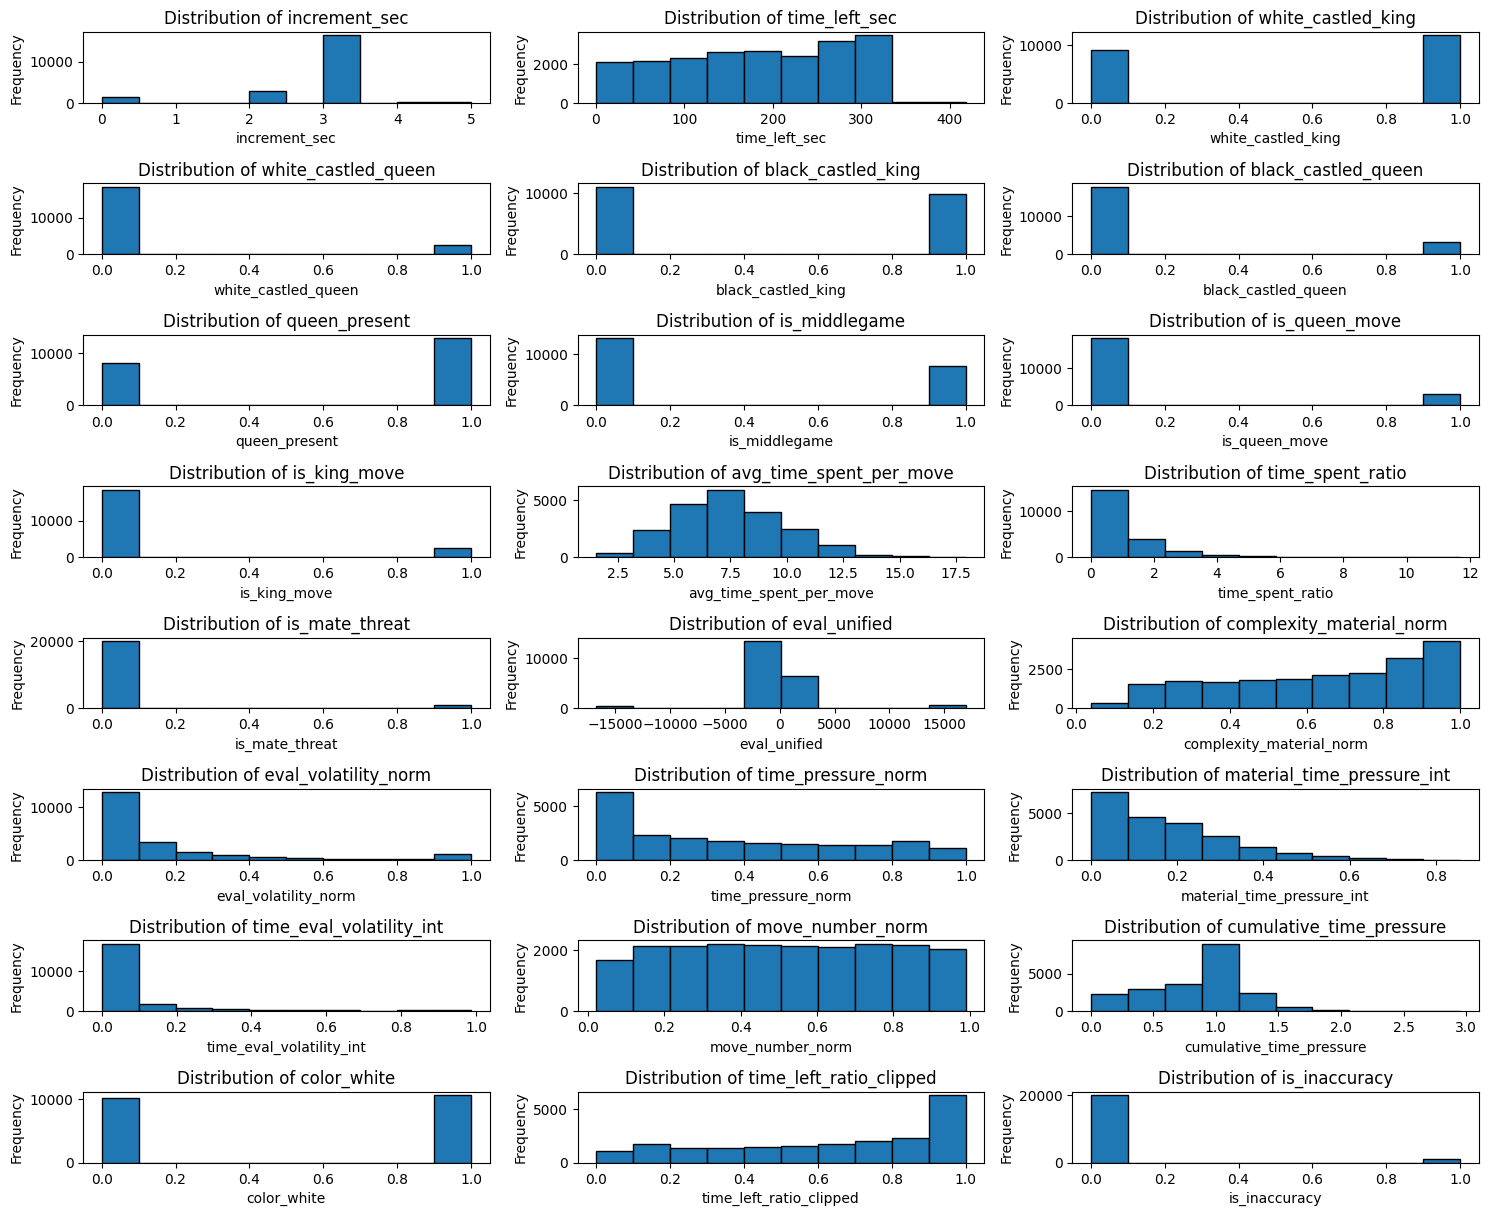

In [100]:
columns_df = train_df.columns

num_cols = len(columns_df)
n_cols = 3
n_rows = 20

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 30))
axes = axes.flatten()

for i, col in enumerate(columns_df):
    axes[i].hist(train_df[col], bins=10, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [101]:
X_train.columns

Index(['increment_sec', 'time_left_sec', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_middlegame', 'is_queen_move', 'is_king_move',
       'avg_time_spent_per_move', 'time_spent_ratio', 'is_mate_threat',
       'eval_unified', 'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

In [102]:
log_features = [
    'increment_sec',     
    'time_spent_ratio',  
]

for col in log_features:
    cap = X_train[col].quantile(0.95)
    X_train[col] = np.log1p(X_train[col].clip(0, cap))
    X_test[col]  = np.log1p(X_test[col].clip(0, cap))

In [103]:
# eval_unified
for col in ['eval_unified']:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col]  = X_test[col].clip(lo, hi)

In [104]:
scale_only_features = [
    # Uniform or near-uniform — no skew to fix
    'time_left_sec',              # uniform 
    'complexity_material_norm',   # roughly uniform increasing
    'move_number_norm',           # roughly uniform

    # Bell-shaped / near-normal
    'avg_time_spent_per_move',    # bell-shaped 
    'cumulative_time_pressure',   # bell-shaped 

    # Already 0-1, right-skewed or zero-inflated
    'eval_volatility_norm',
    'time_pressure_norm',
    'material_time_pressure_int',
    'time_eval_volatility_int',
    'time_left_ratio_clipped',    # left-skewed but bounded
]

In [105]:
from sklearn.preprocessing import StandardScaler
import numpy as np

log_cols = ['increment_sec', 'time_spent_ratio']
for col in log_cols:
    cap = X_train[col].quantile(0.95)
    X_train[col] = np.log1p(X_train[col].clip(0, cap))
    X_test[col]  = np.log1p(X_test[col].clip(0, cap))

lo = X_train['eval_unified'].quantile(0.01)
hi = X_train['eval_unified'].quantile(0.99)
X_train['eval_unified'] = X_train['eval_unified'].clip(lo, hi)
X_test['eval_unified']  = X_test['eval_unified'].clip(lo, hi)

scale_cols = log_cols + ['eval_unified'] + scale_only_features

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

In [106]:
scaled_train_df = pd.concat([X_train, y_train], axis=1)

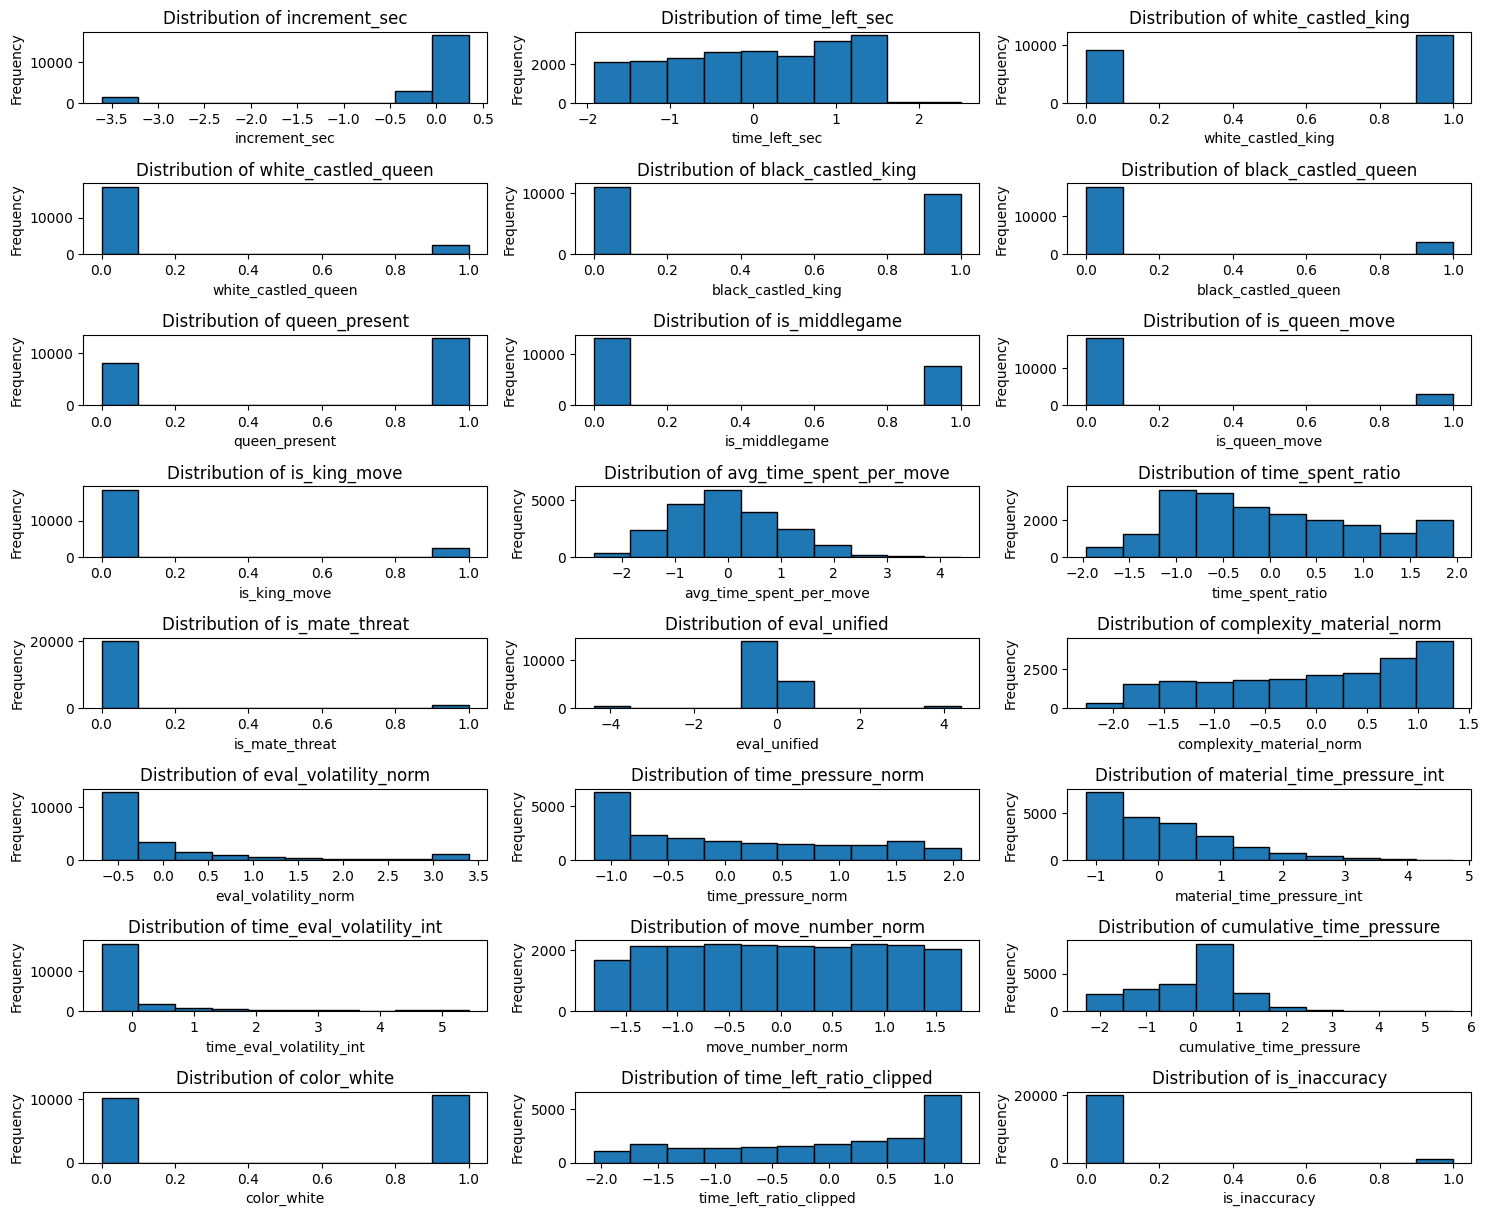

In [107]:
columns_df = scaled_train_df.columns

num_cols = len(columns_df)
n_cols = 3
n_rows = 20

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 30))
axes = axes.flatten()

for i, col in enumerate(columns_df):
    axes[i].hist(scaled_train_df[col], bins=10, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [108]:
X_train.to_csv('model_data/scaled_inaccuracy_blitz_X_train.csv', index=False)
X_test.to_csv('model_data/scaled_inaccuracy_blitz_X_test.csv', index=False)

In [109]:
y_train.to_csv('model_data/inaccuracy_blitz_y_train.csv', index=False)
y_test.to_csv('model_data/inaccuracy_blitz_y_test.csv', index=False)